This is part of a tutorial series. We recommend following them in order, starting with [Part 0: Welcome to `musica`](0.%20Welcome%20to%20MUSICA.ipynb).

# `tuv-x`: Computing a Subset of Photolysis Rates

The TS1/TSMLT configuration of TUV-x includes 50+ photolysis reactions covering species from the troposphere through the stratosphere, including halogens, sulfur compounds, and many organic species. For simulations that only need a smaller set of reactions — for example, a tropospheric mechanism that doesn't include halogen chemistry — computing the full set is unnecessary work.

TUV-x computes photolysis rate constants by:
1. Solving the radiation field (the expensive radiative transfer calculation, which is independent of the photolysis reaction list)
2. For each photolysis reaction: integrating the product of the radiation field, the species cross section, and the quantum yield over the wavelength grid

Step 2 is repeated for every reaction in the configuration. Removing unused reactions from the config directly reduces the number of these integrals.

This tutorial shows how to select only the reactions your mechanism needs using the `config_string` API.

## 1. Listing Available Reactions

Let's start by seeing what reactions are defined in the TS1/TSMLT configuration.

In [1]:
import json
from musica.tuvx import vTS1

config_path = vTS1.config_file_path()

with open(config_path) as f:
    full_config = json.load(f)

all_reactions = full_config["photolysis"]["reactions"]
print(f"TS1/TSMLT has {len(all_reactions)} photolysis reactions:")
for r in all_reactions:
    reaction_str = r.get("__reaction", "")
    print(f"  {r['name']:20s}  ({reaction_str})")

TS1/TSMLT has 73 photolysis reactions:
  jo2_a                 (O2 + hv -> O + O1D)
  jo2_b                 (O2 + hv -> O + O)
  jo3_a                 (O3 + hv -> O2 + O(1D))
  jo3_b                 (O3 + hv -> O2 + O(3P))
  jn2o                  (N2O + hv -> N2 + O(1D))
  jno2                  (NO2 + hv -> NO + O(3P))
  jn2o5_a               (N2O5 + hv -> NO2 + NO3)
  jn2o5_b               (N2O5 + hv -> NO + O + NO3)
  jhno3                 (HNO3 + hv -> OH + NO2)
  jno3_a                (NO3 + hv -> NO2 + O(3P))
  jno3_b                (NO3 + hv -> NO + O2)
  jch3ooh               (CH3OOH + hv -> CH3O + OH)
  jch2o_a               (CH2O + hv -> H + HCO)
  jch2o_b               (CH2O + hv -> H2 + CO)
  jh2o2                 (H2O2 + hv -> OH + OH)
  jch3cho               (CH3CHO + hv -> CH3 + HCO)
  jpan                  (PAN + hv -> 0.6*CH3CO3 + 0.6*NO2 + 0.4*CH3O2 + 0.4*NO3 + 0.4*CO2)
  jmvk                  (MVK + hv -> 0.7*C3H6 + 0.7*CO + 0.3*CH3O2 + 0.3*CH3CO3)
  jacet            

## 2. Filtering the Configuration

To run TUV-x with a subset of these reactions, we:

1. Load the full TS1/TSMLT JSON configuration
2. Filter `config["photolysis"]["reactions"]` to keep only the reactions we need
3. Pass the modified configuration as a JSON string to the `TUVX` constructor via `config_string`

The radiative transfer calculation (the dominant cost) is unaffected — it depends on the grids and atmospheric profiles, not the photolysis reaction list. Only the per-reaction integration step is reduced.

> **Note on file paths**: When using `config_string`, relative paths in the configuration are resolved against the current working directory, not the original config file location. The helper function below handles this by temporarily changing to the config directory.

In [2]:
import os
import json
from musica.tuvx import vTS1
from musica.tuvx.tuvx import TUVX
from musica.tuvx.grid_map import GridMap
from musica.tuvx.profile_map import ProfileMap
from musica.tuvx.radiator_map import RadiatorMap


def get_tuvx_with_subset(reaction_names: list[str]) -> TUVX:
    """Create a TUV-x TS1/TSMLT instance that computes only the specified reactions."""
    config_path = vTS1.config_file_path()

    with open(config_path) as f:
        config = json.load(f)

    all_reactions = config["photolysis"]["reactions"]
    all_names = {r["name"] for r in all_reactions}

    unknown = set(reaction_names) - all_names
    if unknown:
        raise ValueError(
            f"Unknown reaction names: {sorted(unknown)}.\n"
            f"Available: {sorted(all_names)}"
        )

    requested = set(reaction_names)
    config["photolysis"]["reactions"] = [
        r for r in all_reactions if r["name"] in requested
    ]

    # Build grids, profiles, and radiators (same as the full TS1/TSMLT setup)
    grids = GridMap()
    grids["height", "km"] = vTS1.height_grid()
    grids["wavelength", "nm"] = vTS1.wavelength_grid()

    height = grids["height", "km"]
    wavelength = grids["wavelength", "nm"]

    profiles = ProfileMap()
    profiles["air", "molecule cm-3"] = vTS1.profile("air", height)
    profiles["O3", "molecule cm-3"] = vTS1.profile("O3", height)
    profiles["O2", "molecule cm-3"] = vTS1.profile("O2", height)
    profiles["temperature", "K"] = vTS1.profile("temperature", height)
    profiles["surface albedo", "none"] = vTS1.profile("surface albedo", wavelength)
    profiles["extraterrestrial flux", "photon cm-2 s-1"] = vTS1.profile(
        "extraterrestrial flux", wavelength)

    radiators = RadiatorMap()
    radiators["aerosol"] = vTS1.radiator("aerosol", height, wavelength)

    # Temporarily change to the config directory so relative paths in the config work
    config_dir = os.path.dirname(os.path.abspath(config_path))
    original_cwd = os.getcwd()
    os.chdir(config_dir)
    try:
        tuvx = TUVX(
            grid_map=grids,
            profile_map=profiles,
            radiator_map=radiators,
            config_string=json.dumps(config)
        )
    finally:
        os.chdir(original_cwd)

    return tuvx

## 3. Running with a Tropospheric Subset

Here we select 11 reactions relevant to a basic tropospheric mechanism, skipping the halogen, sulfur, and stratospheric-only reactions.

In [3]:
import xarray as xr

tropospheric_reactions = [
    "jo2_a",    # O2 + hv -> O + O(1D)
    "jo2_b",    # O2 + hv -> O + O
    "jo3_a",    # O3 + hv -> O2 + O(1D)
    "jo3_b",    # O3 + hv -> O2 + O(3P)
    "jno2",     # NO2 + hv -> NO + O(3P)
    "jno3_a",   # NO3 + hv -> NO2 + O(3P)
    "jno3_b",   # NO3 + hv -> NO + O2
    "jhno3",    # HNO3 + hv -> OH + NO2
    "jh2o2",    # H2O2 + hv -> OH + OH
    "jch2o_a",  # CH2O + hv -> H + HCO
    "jch2o_b",  # CH2O + hv -> H2 + CO
]

print(f"Creating TUV-x with {len(tropospheric_reactions)} of {len(all_reactions)} reactions...")
tuvx_subset = get_tuvx_with_subset(tropospheric_reactions)

results: xr.Dataset = tuvx_subset.run(sza=0.0, earth_sun_distance=1.0)

print("\nSurface-level photolysis rate constants (altitude = 0 km):")
for name in tropospheric_reactions:
    rate = float(results["photolysis_rate_constants"].sel(reaction=name).values[0])
    print(f"  {name:12s}: {rate:.3e} s\u207b\u00b9")

Creating TUV-x with 11 of 73 reactions...

Surface-level photolysis rate constants (altitude = 0 km):
  jo2_a       : 0.000e+00 s⁻¹
  jo2_b       : 3.608e-27 s⁻¹
  jo3_a       : 4.882e-05 s⁻¹
  jo3_b       : 5.015e-04 s⁻¹
  jno2        : 1.105e-02 s⁻¹
  jno3_a      : 2.108e-01 s⁻¹
  jno3_b      : 2.213e-02 s⁻¹
  jhno3       : 8.321e-07 s⁻¹
  jh2o2       : 9.150e-06 s⁻¹
  jch2o_a     : 4.145e-05 s⁻¹
  jch2o_b     : 5.913e-05 s⁻¹


## 4. Comparing Against the Full Configuration

The subset results should be identical to the full TS1/TSMLT configuration for the same reactions, because the radiative transfer calculation is unchanged. Let's verify this.

In [4]:
from musica.tuvx import vTS1

tuvx_full = vTS1.get_tuvx_calculator()
results_full: xr.Dataset = tuvx_full.run(sza=0.0, earth_sun_distance=1.0)

print("Checking that subset results match the full TS1/TSMLT configuration:")
all_match = True
for name in tropospheric_reactions:
    subset_vals = results["photolysis_rate_constants"].sel(reaction=name).values
    full_vals = results_full["photolysis_rate_constants"].sel(reaction=name).values
    import numpy as np
    match = np.allclose(subset_vals, full_vals, rtol=1e-10)
    print(f"  {name:12s}: {'OK' if match else 'MISMATCH'}")
    all_match = all_match and match

print(f"\nAll rates match: {all_match}")

Checking that subset results match the full TS1/TSMLT configuration:
  jo2_a       : OK
  jo2_b       : OK
  jo3_a       : OK
  jo3_b       : OK
  jno2        : OK
  jno3_a      : OK
  jno3_b      : OK
  jhno3       : OK
  jh2o2       : OK
  jch2o_a     : OK
  jch2o_b     : OK

All rates match: True


## 5. Timing Comparison

We can use the `%timeit` magic to measure how much faster the `run()` call is with the subset configuration.
Both instances are already initialised — the grids, profiles, and radiative transfer setup happen at construction time.
What we are timing here is the per-call cost: solving the radiation field plus the per-reaction integrations.
The radiation field solve is identical in both cases; the difference comes entirely from the number of
cross section / quantum yield integrals.

In [5]:
print(f"Timing full TS1/TSMLT ({len(tuvx_full.photolysis_rate_names)} reactions)...")
%timeit tuvx_full.run(sza=0.0, earth_sun_distance=1.0)

print(f"\nTiming subset ({len(tuvx_subset.photolysis_rate_names)} reactions)...")
%timeit tuvx_subset.run(sza=0.0, earth_sun_distance=1.0)

Timing full TS1/TSMLT (73 reactions)...
14.3 ms ± 113 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

Timing subset (11 reactions)...
3.9 ms ± 116 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## 6. Vertical Profiles

Let's plot vertical profiles for a few of the subset reactions to confirm the results look physically reasonable.

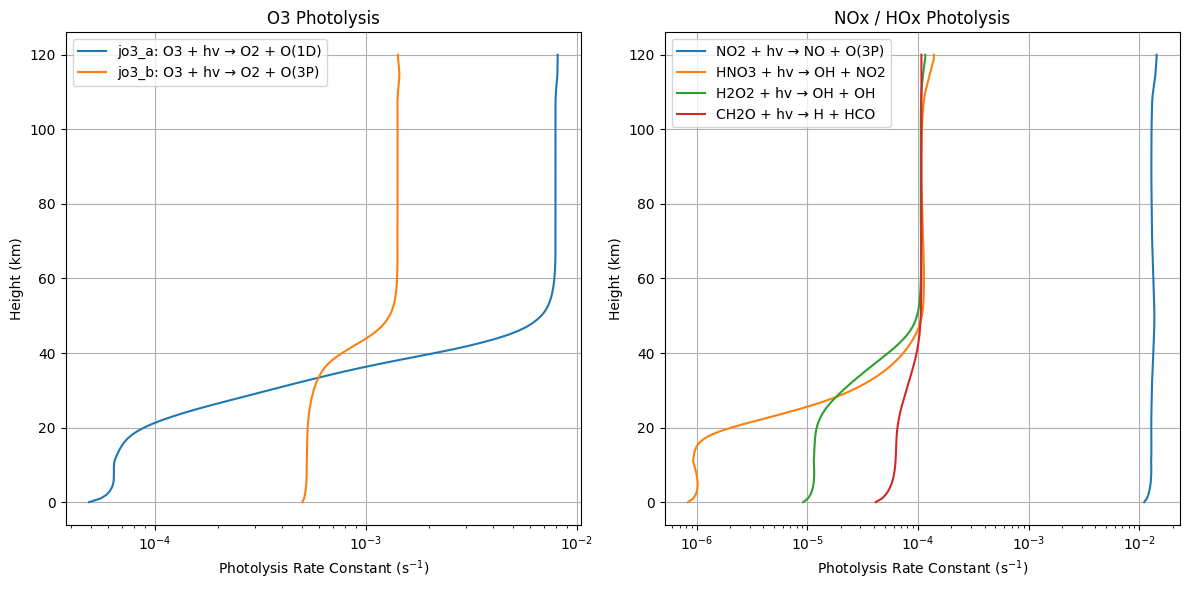

In [7]:
import matplotlib.pyplot as plt

height = results["vertical_edge"].values

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# O3 photolysis channels
axes[0].semilogx(
    results["photolysis_rate_constants"].sel(reaction="jo3_a").values, height,
    label="jo3_a: O3 + hv → O2 + O(1D)"
)
axes[0].semilogx(
    results["photolysis_rate_constants"].sel(reaction="jo3_b").values, height,
    label="jo3_b: O3 + hv → O2 + O(3P)"
)
axes[0].set_xlabel("Photolysis Rate Constant (s$^{-1}$)")
axes[0].set_ylabel("Height (km)")
axes[0].set_title("O3 Photolysis")
axes[0].legend()
axes[0].grid(True)

# NOx and HOx channels
for name, label in [
    ("jno2",    "NO2 + hv → NO + O(3P)"),
    ("jhno3",   "HNO3 + hv → OH + NO2"),
    ("jh2o2",   "H2O2 + hv → OH + OH"),
    ("jch2o_a", "CH2O + hv → H + HCO"),
]:
    axes[1].semilogx(
        results["photolysis_rate_constants"].sel(reaction=name).values, height,
        label=label
    )
axes[1].set_xlabel("Photolysis Rate Constant (s$^{-1}$)")
axes[1].set_ylabel("Height (km)")
axes[1].set_title("NOx / HOx Photolysis")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 7. Summary

To run TUV-x with a reduced set of photolysis reactions:

1. Load the JSON configuration with `json.load(open(vTS1.config_file_path()))`
2. Filter `config["photolysis"]["reactions"]` to only the reactions your mechanism needs
3. Change to the config directory (`os.chdir`) so relative data file paths resolve correctly
4. Pass the modified config as a JSON string via `TUVX(..., config_string=json.dumps(config))`

The radiative transfer calculation is shared across all photolysis reactions and is not affected by the reaction list. Only the per-reaction cross section integration step is reduced, so savings scale with the fraction of reactions removed.

The results for any given reaction are numerically identical to the full configuration run, since the radiation field is unchanged.